# Data Visualization — Green Bond & Corporate Performance (ASEAN)

Publication-quality exploratory visualizations for the panel dataset.

**Contents**
1. Setup & Data Loading
2. Trend Analysis — ASEAN-Level Averages
3. Trend Analysis — Country Breakdown
4. Distribution & Outlier Analysis
5. Country-Level Distribution Comparison
6. DID Pre-Check — Parallel Trends
7. Correlation Heatmap

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#2d3139",
    "axes.labelcolor": "#c9d1d9",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "text.color": "#c9d1d9",
    "grid.color": "#21262d",
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "figure.titlesize": 16,
    "figure.titleweight": "bold",
    "legend.framealpha": 0.15,
    "legend.edgecolor": "#30363d",
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
})

PALETTE = {
    "Philippines": "#58a6ff",
    "Thailand":    "#f78166",
    "Malaysia":    "#7ee787",
    "Vietnam":     "#d2a8ff",
}
GRAD_COLORS = ["#58a6ff", "#7ee787", "#f78166", "#d2a8ff", "#f0883e"]

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv("../processed_data/final_engineered_panel_data.csv")

# Reconstruct 'year' from dummy columns (base = 2015)
year_cols = sorted([c for c in df.columns if c.startswith("Year_")])
df["year"] = 2015  # base
for col in year_cols:
    yr = int(col.split("_")[1])
    df.loc[df[col] == 1, "year"] = yr

# Reconstruct 'country' from dummy columns (base = Philippines)
df["country"] = "Philippines"
df.loc[df["country_Thailand"] == 1, "country"] = "Thailand"
df.loc[df["country_Malaysia"] == 1, "country"] = "Malaysia"
df.loc[df["country_Vietnam"] == 1, "country"] = "Vietnam"

print(f"Panel: {df.shape[0]:,} obs  |  {df['company'].nunique():,} firms  |  "
      f"Years {df['year'].min()}–{df['year'].max()}  |  "
      f"Countries: {', '.join(sorted(df['country'].unique()))}")
print(f"\nGreen bond issues: {int(df['green_bond_issue'].sum())}  |  "
      f"Active green bonds: {int(df['green_bond_active'].sum())}")
print(df.groupby("country")["company"].nunique().rename("firms").to_frame().T)

Panel: 13,688 obs  |  1,453 firms  |  Years 2015–2024  |  Countries: Malaysia, Philippines, Thailand, Vietnam

Green bond issues: 19  |  Active green bonds: 59
country  Malaysia  Philippines  Thailand  Vietnam
firms           4          259       825      365


## 2. Trend Analysis — ASEAN-Level Averages

Average trajectory of core financial & environmental variables across the full panel (2015-2024).

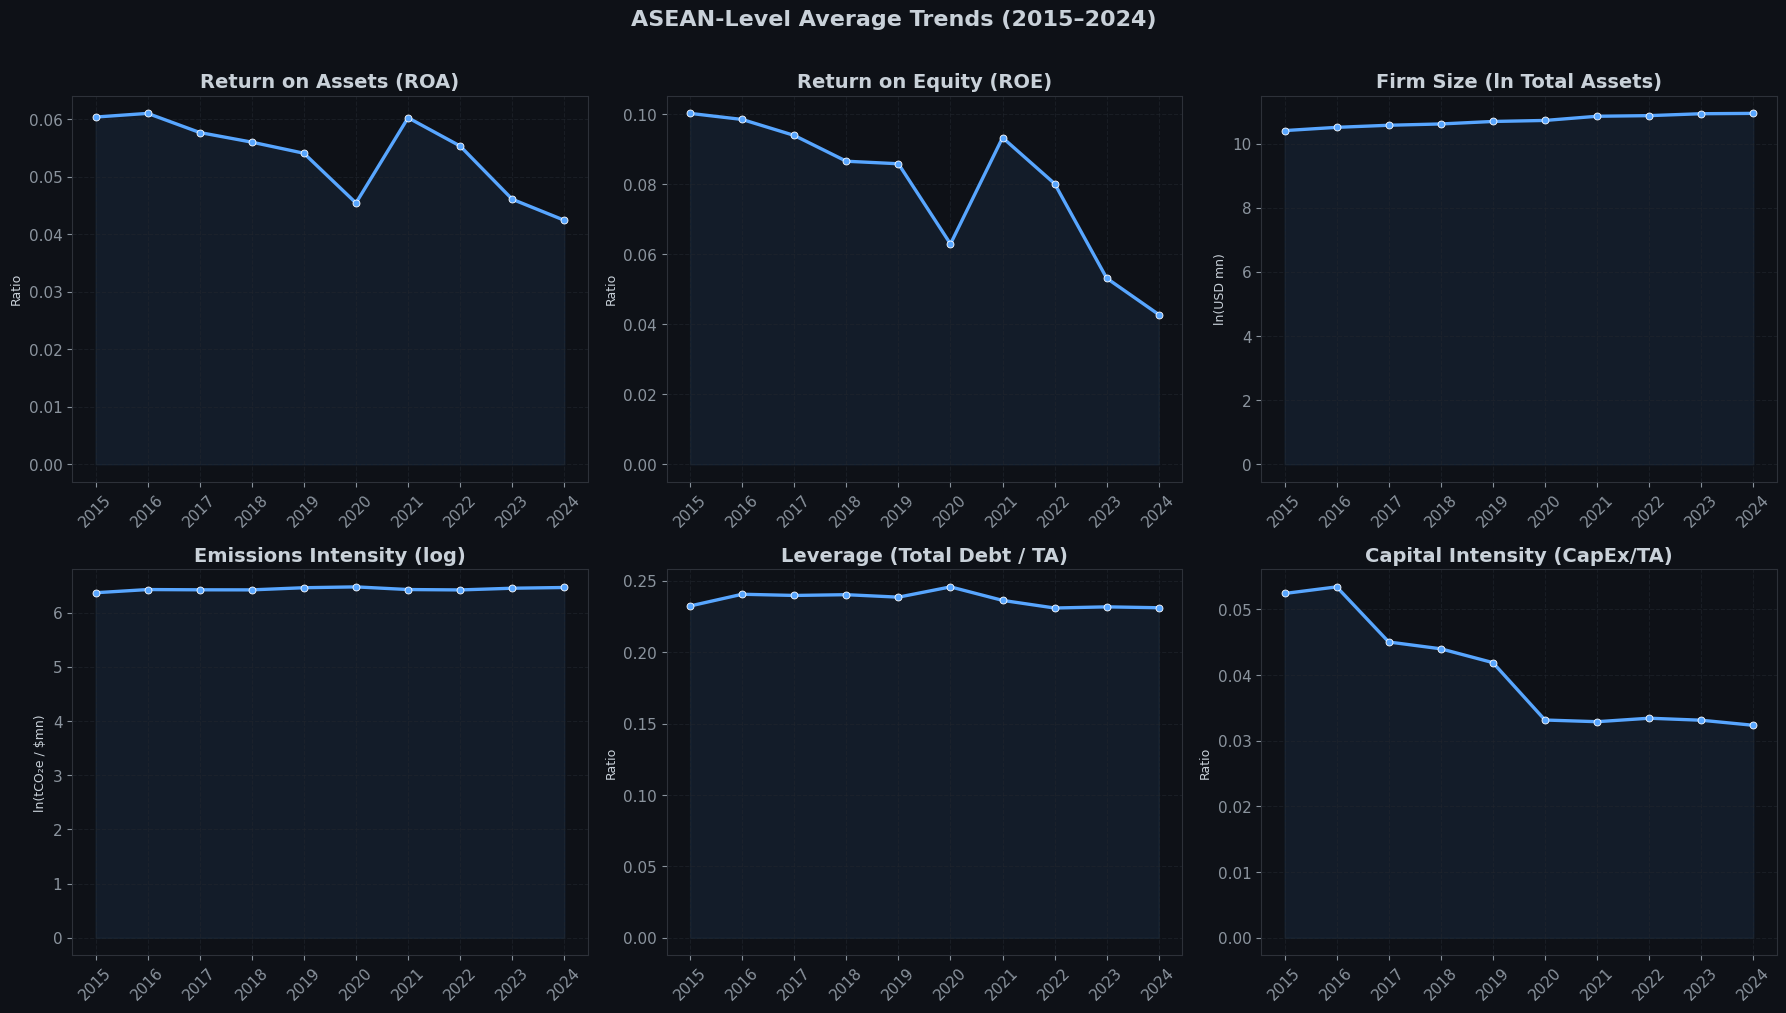

In [2]:
# ── ASEAN-level trend plots ────────────────────────────────────────────────
trend_vars = {
    "return_on_assets":       ("Return on Assets (ROA)",       "Ratio"),
    "return_on_equity_total": ("Return on Equity (ROE)",       "Ratio"),
    "ln_total_assets":        ("Firm Size (ln Total Assets)",  "ln(USD mn)"),
    "ln_emissions_intensity": ("Emissions Intensity (log)",    "ln(tCO₂e / $mn)"),
    "Leverage":               ("Leverage (Total Debt / TA)",   "Ratio"),
    "Capital_Intensity":      ("Capital Intensity (CapEx/TA)", "Ratio"),
}

agg = df.groupby("year")[list(trend_vars.keys())].mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("ASEAN-Level Average Trends (2015–2024)", y=1.01)

for ax, (var, (title, ylabel)) in zip(axes.flat, trend_vars.items()):
    vals = agg[var]
    ax.plot(vals.index, vals.values, color="#58a6ff", linewidth=2.4,
            marker="o", markersize=5, markeredgecolor="white", markeredgewidth=0.6)
    ax.fill_between(vals.index, vals.values, alpha=0.08, color="#58a6ff")
    ax.set_title(title)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlabel("")
    ax.grid(True)
    ax.set_xticks(range(2015, 2025))
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
# plt.savefig("processed_data/trend_asean.png")
plt.show()

## 3. Trend Analysis — Country Breakdown

Same key variables, disaggregated by ASEAN country.

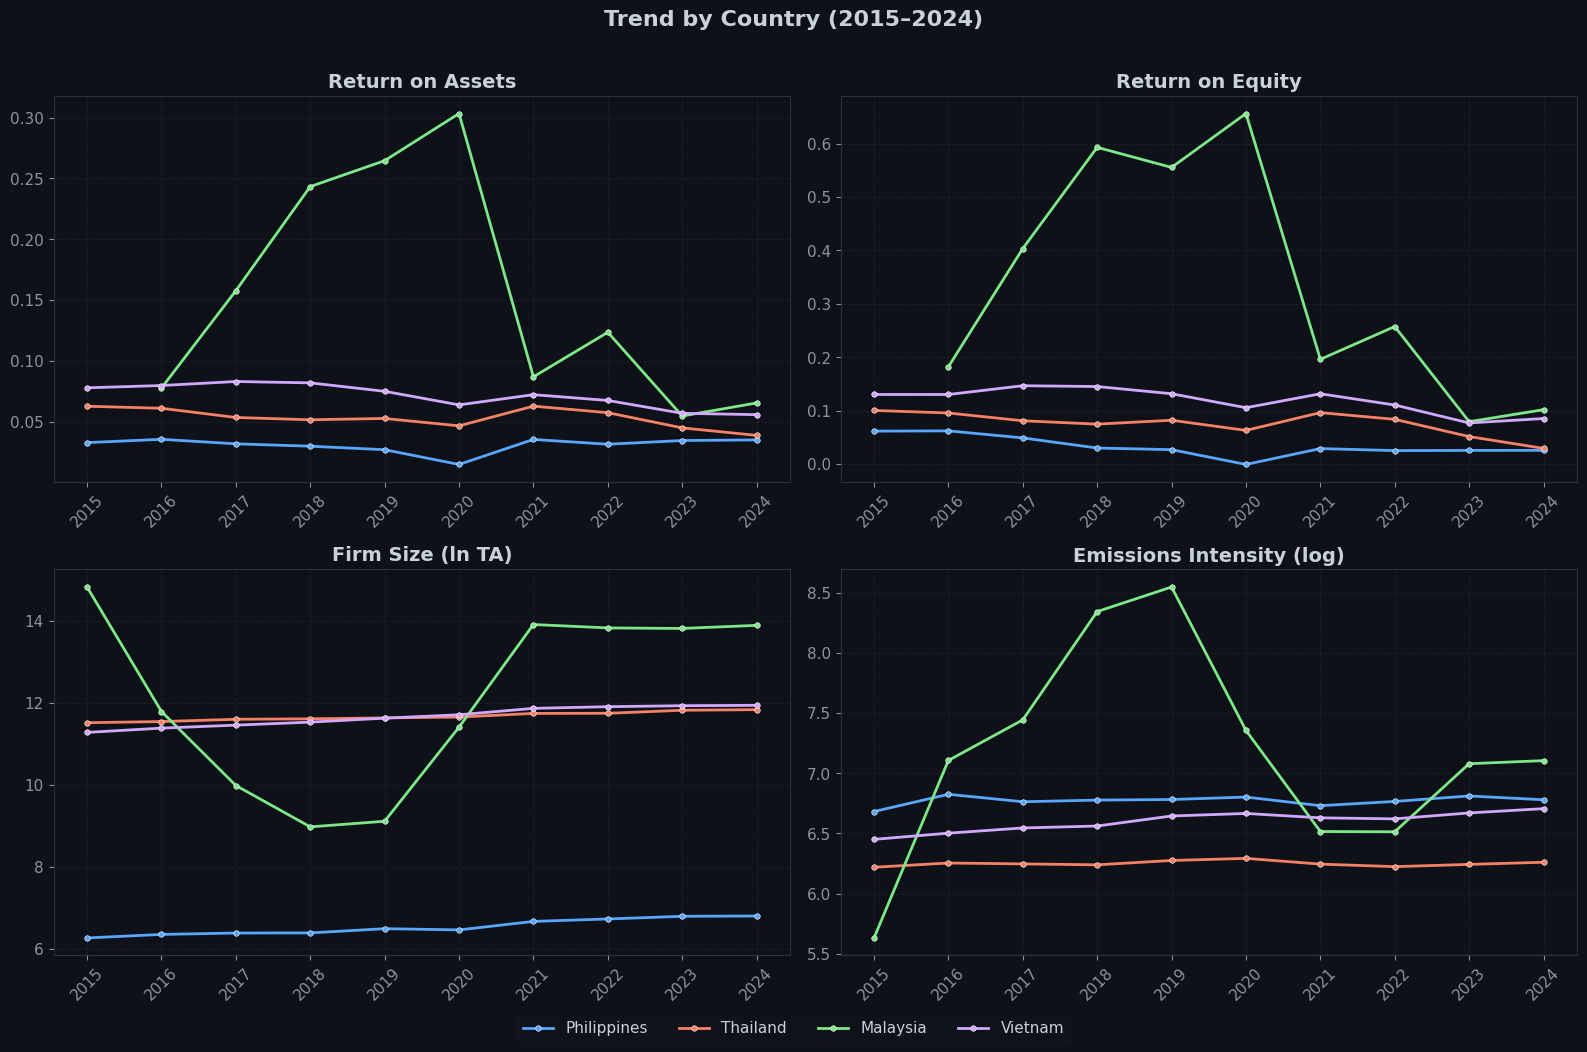

In [3]:
# ── Country-level trend plots ──────────────────────────────────────────────
country_vars = {
    "return_on_assets":       "Return on Assets",
    "return_on_equity_total": "Return on Equity",
    "ln_total_assets":        "Firm Size (ln TA)",
    "ln_emissions_intensity": "Emissions Intensity (log)",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Trend by Country (2015–2024)", y=1.01)

for ax, (var, title) in zip(axes.flat, country_vars.items()):
    for country, color in PALETTE.items():
        sub = df[df["country"] == country].groupby("year")[var].mean()
        ax.plot(sub.index, sub.values, label=country, color=color,
                linewidth=2, marker="o", markersize=4,
                markeredgecolor="white", markeredgewidth=0.4)
    ax.set_title(title)
    ax.grid(True)
    ax.set_xticks(range(2015, 2025))
    ax.tick_params(axis="x", rotation=45)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4,
           fontsize=11, bbox_to_anchor=(0.5, -0.03),
           frameon=True, facecolor="#161b22", edgecolor="#30363d")

plt.tight_layout()
# plt.savefig("processed_data/trend_country.png")
plt.show()

## 4. Distribution & Outlier Analysis

Violin plots to visualise the spread and density of key continuous variables.

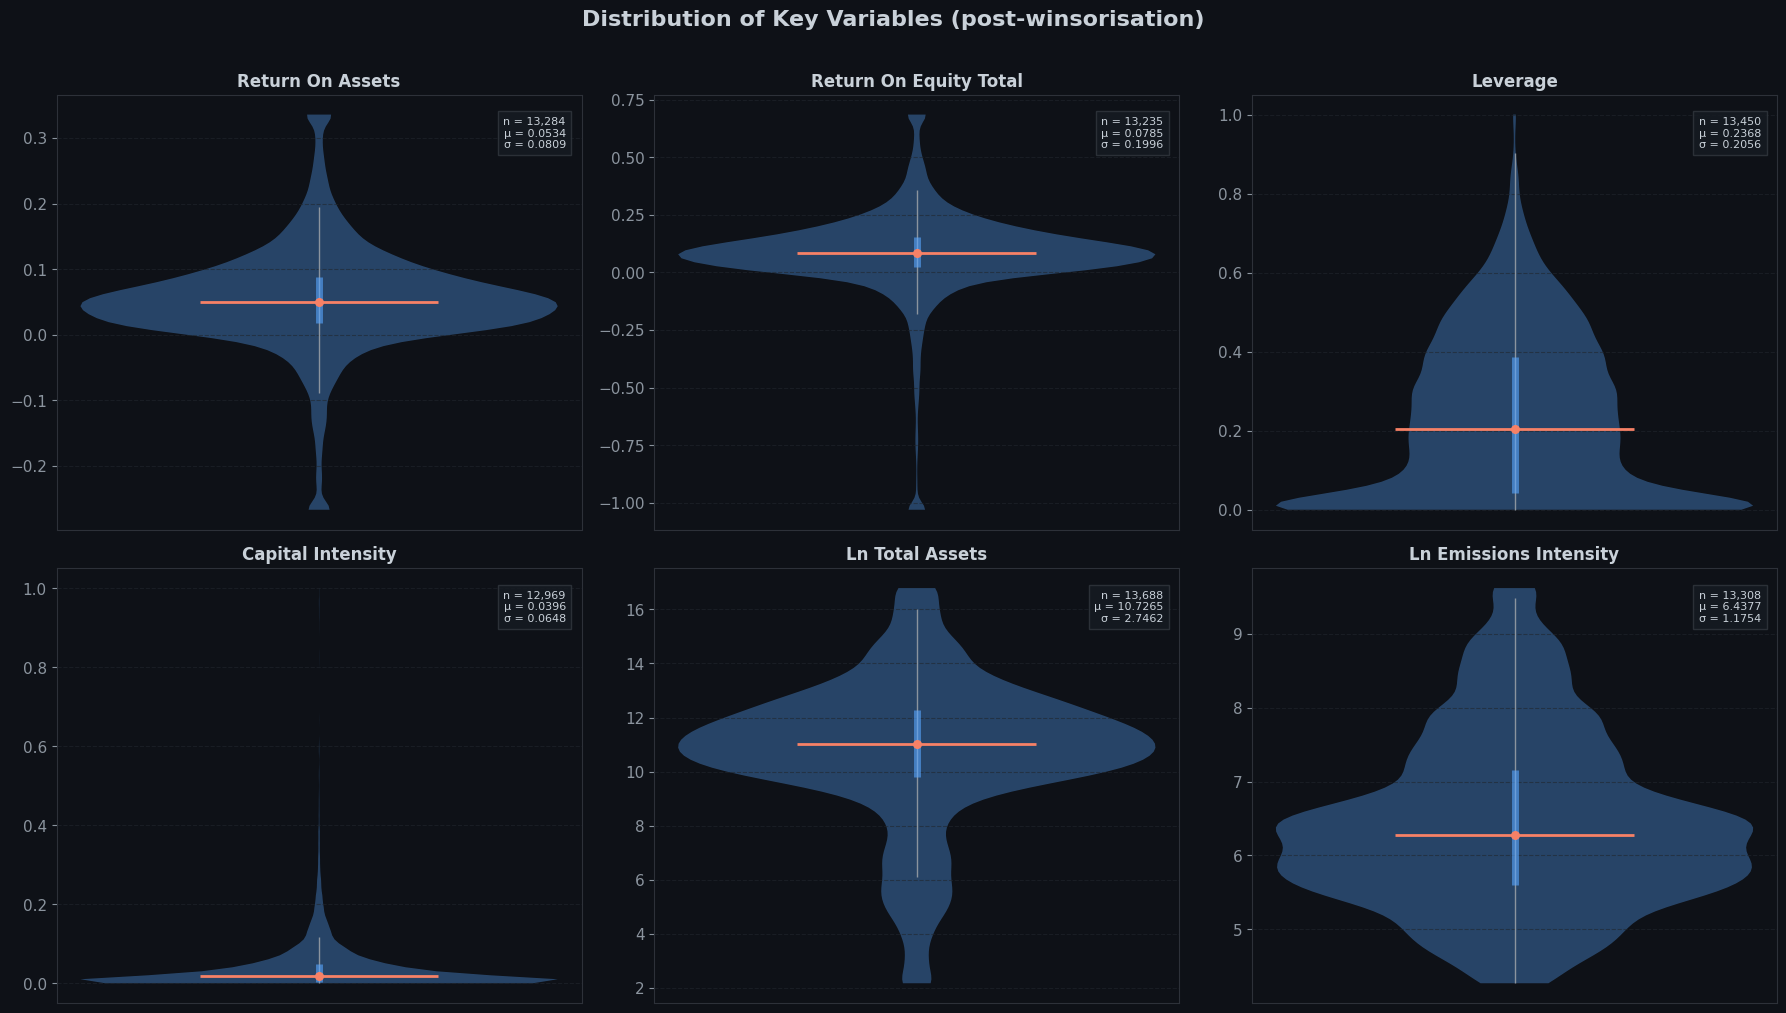

In [5]:
# ── Violin + strip plots for key variables ─────────────────────────────────
dist_vars = ["return_on_assets", "return_on_equity_total",
             "Leverage", "Capital_Intensity",
             "ln_total_assets", "ln_emissions_intensity"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distribution of Key Variables (post-winsorisation)", y=1.01)

for ax, var in zip(axes.flat, dist_vars):
    data = df[var].dropna()
    parts = ax.violinplot(data, positions=[0], showmedians=True,
                          showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor("#58a6ff")
        pc.set_alpha(0.35)
    parts["cmedians"].set_color("#f78166")
    parts["cmedians"].set_linewidth(2)

    # Overlay box
    q1, med, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    whisker_lo = data[data >= q1 - 1.5 * iqr].min()
    whisker_hi = data[data <= q3 + 1.5 * iqr].max()
    ax.vlines(0, whisker_lo, whisker_hi, color="#8b949e", linewidth=1)
    ax.vlines(0, q1, q3, color="#58a6ff", linewidth=5, alpha=0.6)
    ax.scatter([0], [med], color="#f78166", zorder=5, s=30)

    ax.set_title(var.replace("_", " ").title(), fontsize=12)
    ax.set_xticks([])
    ax.grid(True, axis="y")

    # Annotate stats
    ax.text(0.97, 0.95, f"n = {len(data):,}\nμ = {data.mean():.4f}\nσ = {data.std():.4f}",
            transform=ax.transAxes, fontsize=8, va="top", ha="right",
            bbox=dict(facecolor="#161b22", edgecolor="#30363d", alpha=0.85, pad=4),
            color="#c9d1d9")

plt.tight_layout()
# plt.savefig("processed_data/distributions.png")
plt.show()

## 5. Country-Level Distribution Comparison

Side-by-side box plots comparing financial & environmental metrics across countries.

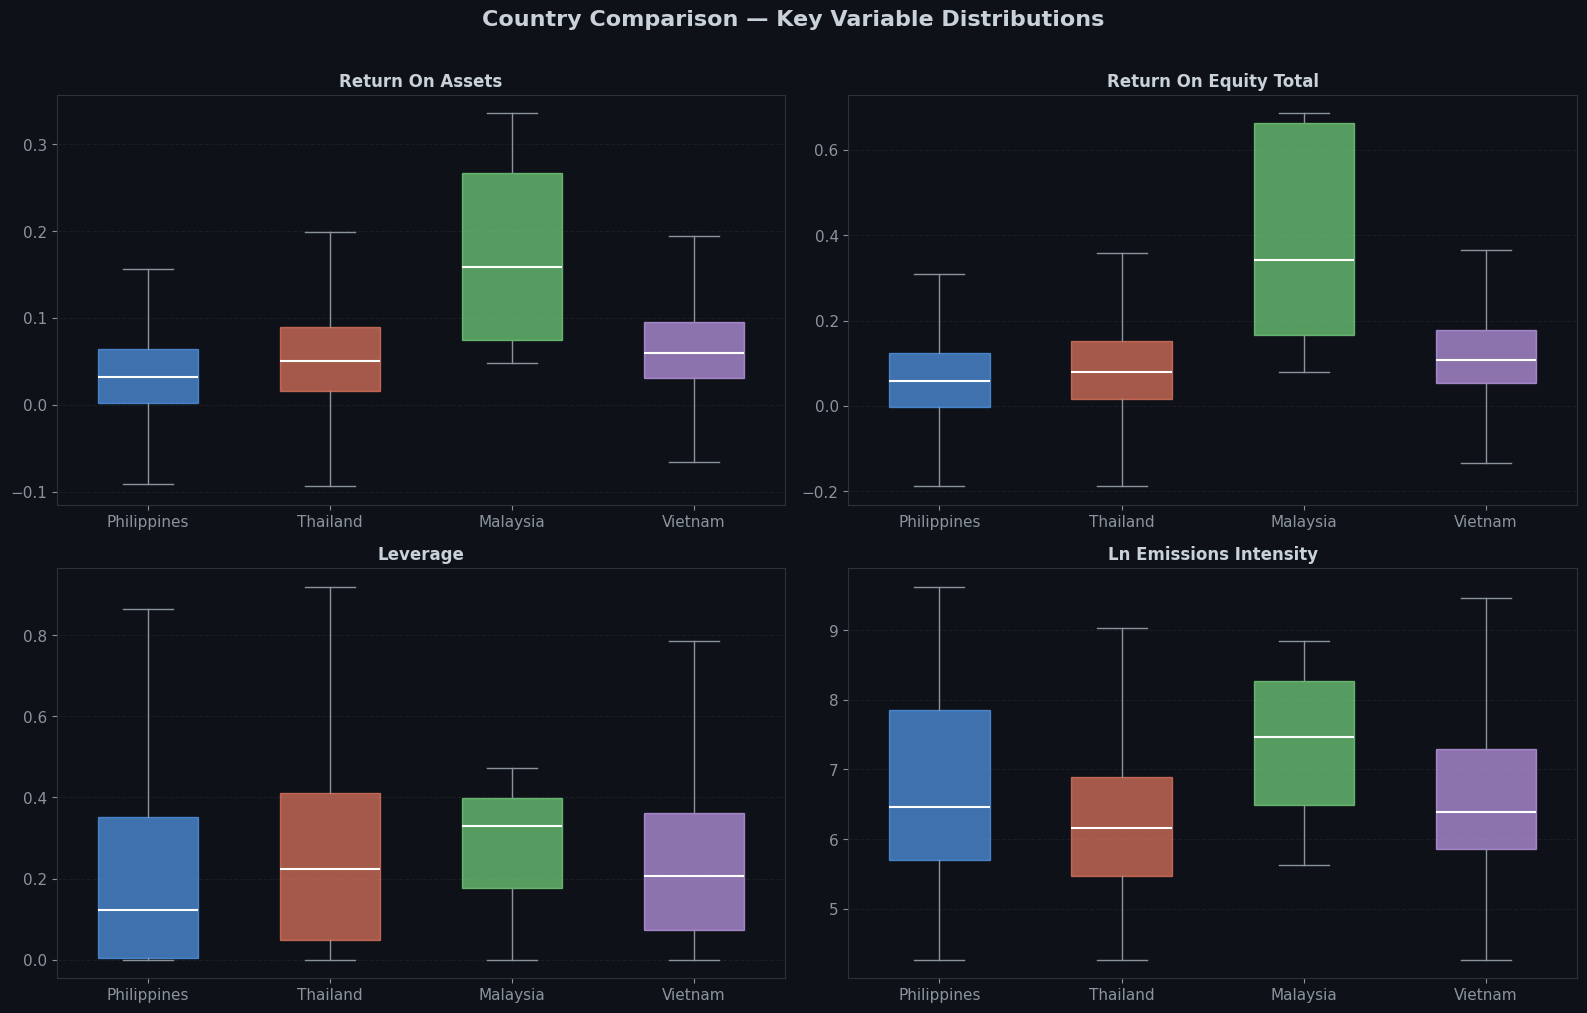

In [6]:
# ── Country comparison box plots ────────────────────────────────────────────
compare_vars = ["return_on_assets", "return_on_equity_total",
                "Leverage", "ln_emissions_intensity"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Country Comparison — Key Variable Distributions", y=1.01)

country_order = ["Philippines", "Thailand", "Malaysia", "Vietnam"]
colors = [PALETTE[c] for c in country_order]

for ax, var in zip(axes.flat, compare_vars):
    data_list = [df[df["country"] == c][var].dropna() for c in country_order]
    bp = ax.boxplot(data_list, labels=country_order, patch_artist=True,
                    widths=0.55, showfliers=False,
                    medianprops=dict(color="white", linewidth=1.5),
                    whiskerprops=dict(color="#8b949e"),
                    capprops=dict(color="#8b949e"))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
        patch.set_edgecolor(color)
    ax.set_title(var.replace("_", " ").title(), fontsize=12)
    ax.grid(True, axis="y")

plt.tight_layout()
# plt.savefig("processed_data/country_comparison.png")
plt.show()

## 6. DID Pre-Check — Parallel Trends (Issuers vs. Non-Issuers)

Visual comparison of average performance trajectories for green-bond issuers (treatment) versus non-issuers (control).
The parallel-trends assumption requires that pre-treatment trends are similar.

Treatment firms (ever issued green bond): 15
Control firms: 1438


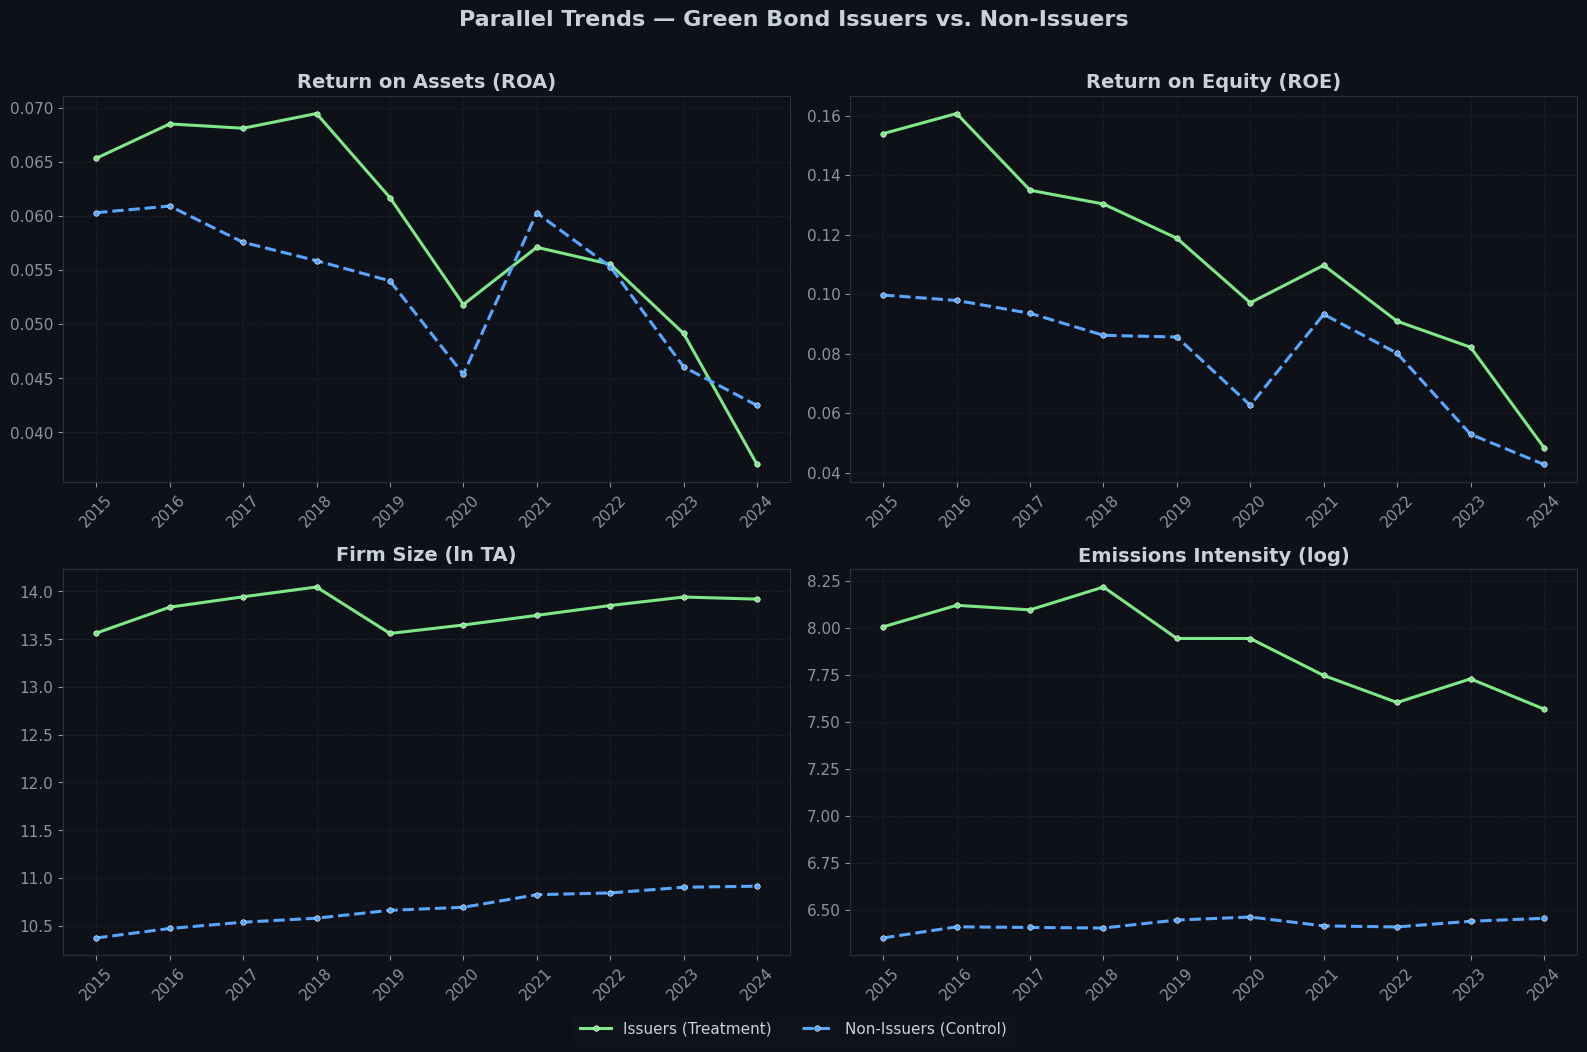

In [7]:
# ── Identify treatment group (firms that EVER issued a green bond) ─────────
ever_issued = df.groupby("company")["green_bond_issue"].max()
treatment_firms = set(ever_issued[ever_issued == 1].index)
df["treatment"] = df["company"].isin(treatment_firms).astype(int)

print(f"Treatment firms (ever issued green bond): {len(treatment_firms)}")
print(f"Control firms: {df['company'].nunique() - len(treatment_firms)}")

# ── Parallel trend plots ──────────────────────────────────────────────────
did_vars = {
    "return_on_assets":       "Return on Assets (ROA)",
    "return_on_equity_total": "Return on Equity (ROE)",
    "ln_total_assets":        "Firm Size (ln TA)",
    "ln_emissions_intensity": "Emissions Intensity (log)",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Parallel Trends — Green Bond Issuers vs. Non-Issuers", y=1.01)

treat_color = "#7ee787"
ctrl_color  = "#58a6ff"

for ax, (var, title) in zip(axes.flat, did_vars.items()):
    for grp, label, color, ls in [(1, "Issuers (Treatment)", treat_color, "-"),
                                   (0, "Non-Issuers (Control)", ctrl_color, "--")]:
        sub = df[df["treatment"] == grp].groupby("year")[var].mean()
        ax.plot(sub.index, sub.values, label=label, color=color,
                linewidth=2.2, linestyle=ls, marker="o", markersize=4,
                markeredgecolor="white", markeredgewidth=0.4)
    ax.set_title(title)
    ax.grid(True)
    ax.set_xticks(range(2015, 2025))
    ax.tick_params(axis="x", rotation=45)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.03),
           frameon=True, facecolor="#161b22", edgecolor="#30363d")

plt.tight_layout()
# plt.savefig("processed_data/parallel_trends.png")
plt.show()

## 7. Correlation Heatmap

Pearson correlations among the regression variables. `total_assets` is excluded (already transformed to `ln_total_assets`).

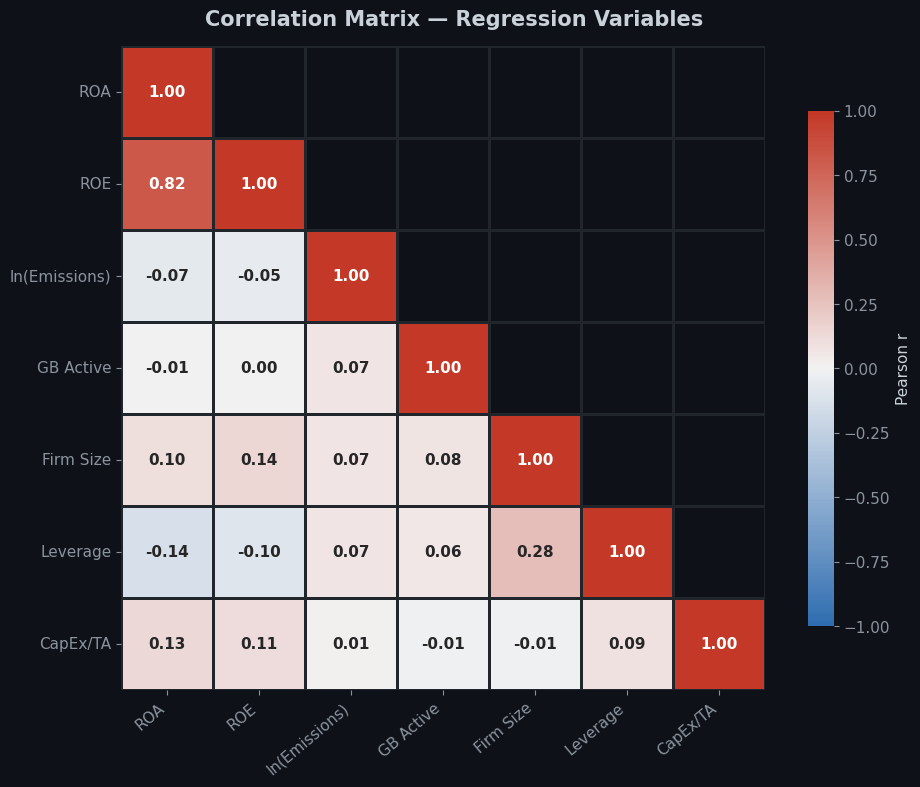

In [8]:
# ── Correlation heatmap ────────────────────────────────────────────────────
corr_vars = [
    "return_on_assets",
    "return_on_equity_total",
    "ln_emissions_intensity",
    "green_bond_active",
    "ln_total_assets",       # = Firm_Size
    "Leverage",
    "Capital_Intensity",
]

corr_labels = [
    "ROA",
    "ROE",
    "ln(Emissions)",
    "GB Active",
    "Firm Size",
    "Leverage",
    "CapEx/TA",
]

corr = df[corr_vars].corr()

# Custom diverging palette
cmap = sns.diverging_palette(250, 15, s=85, l=45, as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("Correlation Matrix — Regression Variables", y=0.98, fontsize=15)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.8, linecolor="#21262d",
            xticklabels=corr_labels, yticklabels=corr_labels,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"},
            annot_kws={"size": 11, "weight": "bold"},
            ax=ax)
ax.tick_params(axis="both", labelsize=11)
plt.xticks(rotation=40, ha="right")

plt.tight_layout()
# plt.savefig("processed_data/correlation_matrix.png")
plt.show()